<a href="https://colab.research.google.com/github/GUSNS083/ML/blob/main/Logistic_Regression_for_Binary_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path=r"/content/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df=pd.read_csv(file_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df=df.dropna()

df['Churn']=df['Churn'].map({'Yes':1,'No':0})
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [6]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False


In [7]:
df_encoded.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'customerID_0003-MKNFE', 'customerID_0004-TLHLJ',
       'customerID_0011-IGKFF', 'customerID_0013-EXCHZ',
       'customerID_0013-MHZWF',
       ...
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object', length=7062)

In [8]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn',axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)

X_test

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
974,0,59,75.95,4542.35,False,False,False,False,False,False,...,False,True,False,True,False,True,True,True,False,False
619,0,7,78.55,522.95,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4289,0,54,20.10,1079.45,False,False,False,False,False,False,...,True,False,True,False,False,True,False,False,False,True
3721,0,2,20.65,38.70,False,False,False,False,False,False,...,True,False,True,False,False,False,False,False,False,True
4533,0,71,105.15,7555.00,False,False,False,False,False,False,...,False,True,False,True,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4829,0,12,45.00,524.35,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
5176,0,26,45.80,1147.00,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2750,0,3,19.45,69.25,False,False,False,False,False,False,...,True,False,True,False,True,False,True,False,False,True
4432,0,37,40.55,1390.85,False,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,True


In [9]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix and Classification Report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 78.96%
Confusion Matrix:
 [[904 129]
 [167 207]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.62      0.55      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



In [11]:
y_prob=model.predict_proba(X_test)[:,-1]
fpr,tpr,thresholds = roc_curve(y_test,y_prob)
auc_score=roc_auc_score(y_test,y_prob)
auc_score

np.float64(0.8307522868339452)

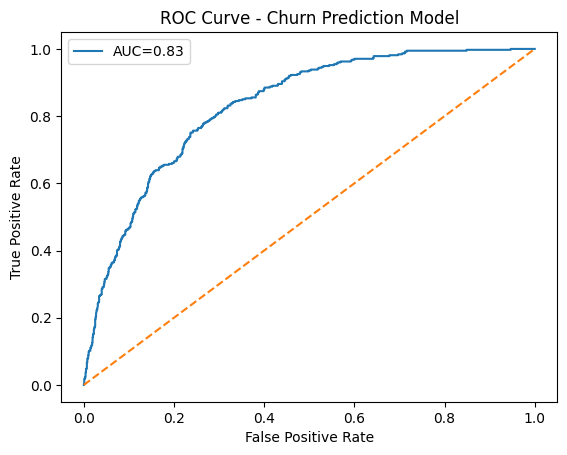

In [12]:
plt.plot(fpr,tpr,label=f'AUC={auc_score:.2f}')
plt.plot([0,1],[0,1],linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Churn Prediction Model")

plt.legend()
plt.show()

In [13]:
# Coefficients and Odds Ratios
coefficients = model.coef_[0]
odds_ratios = np.exp(coefficients)


# Display feature importance using coefficients and odds ratios
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients,
    'Odds Ratio': odds_ratios
})
print("\nFeature Importance (Coefficient and Odds Ratio):")
feature_importance.sort_values(by='Coefficient', ascending=False).head(20)


Feature Importance (Coefficient and Odds Ratio):


,Feature,Coefficient,Odds Ratio
7041,InternetService_Fiber optic,0.752859,2.123061
4474,customerID_6323-AYBRX,0.693282,2.000269
411,customerID_0607-DAAHE,0.693016,1.999739
2450,customerID_3512-IZIKN,0.690935,1.995581
711,customerID_1043-YCUTE,0.690155,1.994024
4624,customerID_6532-YLWSI,0.690051,1.993818
6086,customerID_8631-NBHFZ,0.689207,1.992135
5222,customerID_7359-SSBJK,0.687310,1.988360
6047,customerID_8580-QVLOC,0.687252,1.988245
6391,customerID_9063-ZGTUY,0.685829,1.985418


In [14]:
feature_importance.sort_values(by='Coefficient', ascending=False).tail(20)

,Feature,Coefficient,Odds Ratio
627,customerID_0916-QOFDP,-0.521015,0.593917
2317,customerID_3318-NMQXL,-0.528116,0.589715
2409,customerID_3452-GWUIN,-0.529673,0.588797
823,customerID_1197-BVMVG,-0.532190,0.587317
5124,customerID_7225-CBZPL,-0.533316,0.586656
6165,customerID_8739-XNIKG,-0.533785,0.586382
5360,customerID_7577-SWIFR,-0.534752,0.585815
3472,customerID_4927-WWOOZ,-0.540374,0.582531
4196,customerID_5935-FCCNB,-0.540698,0.582342
2434,customerID_3489-HHPFY,-0.541178,0.582062
